In [1]:
import glob
import numpy as np
import seaborn as sns
import scanpy as sc
import pandas as pd
import ast
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from PIL import Image
from IPython.display import display

from mmidas.cplMixVAE import cpl_mixVAE
from mmidas.utils.cluster_analysis import K_selection
from mmidas.eval import summarize_inference
from mmidas.utils.config_tools import get_paths
from mmidas.utils.data_tools import load_data, get_loaders, generate_colors, split_data_Kfold, Dbh_Retro_loaders, load_mixed_file

%load_ext autoreload
%autoreload 2

In [2]:
toml_file = 'pyproject.toml'
tag = 'Retroseq_Dbh'
platform = 'Dbh'
device = 'cpu'
config = get_paths(toml_file=toml_file)
data_file = config['paths']['main_dir'] / config['paths']['data_path'] / config['data'][f'{tag}_file']
Dbh_Retroseq_data = load_data(file=data_file)
indx = Dbh_Retroseq_data['dataset'] == platform
Dbh_Retroseq_data['log1p'] = Dbh_Retroseq_data['log1p'][indx]
for key in Dbh_Retroseq_data:
    if key != 'log1p' and key != 'gene_id':
        Dbh_Retroseq_data[key] = Dbh_Retroseq_data[key][indx]

data = Dbh_Retroseq_data
print('Only using Retroseq data')
print('Data shape:', data['log1p'].shape)

/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/pyproject.toml
Getting files directories belong to data...
Getting files directories belong to models...
Number of cells: 5133, Number of genes: 1841
Only using Retroseq data
Data shape: (4608, 1841)


In [117]:
results_path = config['paths']['main_dir'] / config['paths']['saving_path']
available_models = glob.glob(str(results_path) + f'/run_10*narm_{2}*{platform}')

selected_model_file = available_models[0]
trained_models = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_*')
# Get the model parameters from the selected model
param_file = glob.glob(selected_model_file + '/param*')[0]

In [118]:
loaded_param = load_mixed_file(param_file)
params = {}
for pp in loaded_param:
    key = pp.split(":")[0]
    ind_ = pp.find(":")
    try:
        params[key] = float(pp[ind_ + 2:])
        if params[key] == int(params[key]):
            params[key] = int(params[key])
    except ValueError:
        params[key] = pp[ind_ + 2:]
    
    if isinstance(params[key], str):
        try:
            params[key] = ast.literal_eval(params[key])
        except (ValueError, SyntaxError):
            pass
params

{'z_dim': 10,
 'noise_dim': 50,
 'alpha': 0.2,
 'n_gene': 0,
 'n_epoch_aug': 20000,
 'fc_dim_aug': 500,
 'batch_size': 128,
 'affine': False,
 'momentum': 0.01,
 'lr': 0.001,
 'p_drop': 0.25,
 'n_categories': 10,
 'state_dim': 3,
 'n_arm': 2,
 'temp': 1,
 'tau': 0.1,
 'beta': 1,
 'lam': 1,
 'lam_pc': 1,
 'ref_pc': False,
 'latent_dim': 10,
 'n_epoch': 10000,
 'n_epoch_p': 10000,
 'min_con': 0.99,
 'max_prun_it': 9,
 'n_aug_smp': 0,
 'fc_dim': 100,
 'variational': True,
 'augmentation': True,
 's_drop': 0,
 'n_run': 10,
 'hard': False,
 'pre_trained_model': '',
 'n_prun_c': 0,
 'training_mode': 'MSE',
 'seed': 0,
 'cuda': True,
 'toml_file': 'pyproject.toml',
 'data_file': 'Dbh_Retroseq',
 'platform': 'Dbh'}

In [119]:
print('Initializing mixvae model ...')
mixvae = cpl_mixVAE(saving_folder=selected_model_file, device=device)
mixvae.init_model(
                n_categories=params['n_categories'],
                state_dim=params['state_dim'],
                input_dim=data['log1p'].shape[1],
                fc_dim=params['fc_dim'],
                lowD_dim=params['z_dim'],
                n_arm=params['n_arm'],
                tau=params['tau'],
                )

Initializing mixvae model ...
---> Using CPU!


In [120]:
seed = 0        
x_ = data['log1p']
label = data['injection_target']
data_loader, train_loader, _, _, _, _ = get_loaders(x=x_, batch_size=params['batch_size'], seed=params['seed'])                             

In [121]:
trained_models

['/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_10_Cdim_10_Sdim_3_Zdim_10_pdrop_0.25_fcdim_100_aug_True_naug_0_lr_0.001_narm_2_tau_0.1_nbatch_128_nepoch_10000_nepochP_10000_Dbh/model/cpl_mixVAE_model_after_pruning_8_2025-06-02-14-26-19.pth',
 '/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_10_Cdim_10_Sdim_3_Zdim_10_pdrop_0.25_fcdim_100_aug_True_naug_0_lr_0.001_narm_2_tau_0.1_nbatch_128_nepoch_10000_nepochP_10000_Dbh/model/cpl_mixVAE_model_after_pruning_3_2025-06-02-14-26-19.pth',
 '/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_10_Cdim_10_Sdim_3_Zdim_10_pdrop_0.25_fcdim_100_aug_True_naug_0_lr_0.001_narm_2_tau_0.1_nbatch_128_nepoch_10000_nepochP_10000_Dbh/model/cpl_mixVAE_model_after_pruning_6_2025-06-02-14-26-19.pth',
 '/allen/programs/celltypes/workgroups/mousecelltypes/Yeganeh/LC-NE-MixRep/results/run_10_Cdim_10_Sdim_3_Zdim_10_pdrop_0.25_fcdim_100_aug_True_naug_0_lr_0.00

In [122]:
# Loading trained models including before pruning and after pruning
mixvae.variational = False
summary_dict = summarize_inference(mixvae, trained_models, train_loader)

Model /cpl_mixVAE_model_after_pruning_8_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_3_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_6_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_1_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_5_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_2_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_9_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_7_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_before_pruning_2025-06-02-14-26-19.pth
Model /cpl_mixVAE_model_after_pruning_4_2025-06-02-14-26-19.pth


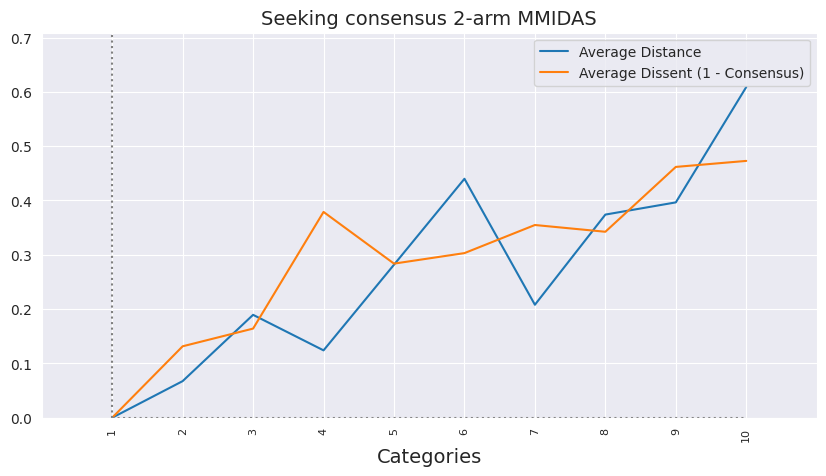

Selected number of clusters: 1 with consensus 1.0


In [127]:
# Plotting average consensus measure to select the number of clusters according to the minimum consensus measure, here 0.95
_, _, _, prun_order = K_selection(summary_dict, mixvae.n_categories, mixvae.n_arm, thr=0.9)

In [128]:
selected_model = glob.glob(selected_model_file + '/model/cpl_mixVAE_model_after_pruning_' + str(mixvae.n_categories - prun_order) + '*')[0]
mixvae.variational = True
outcome = summarize_inference(mixvae, selected_model, data_loader)
model_order = len(np.unique(outcome['pred_label'][0][0]))

Model /cpl_mixVAE_model_after_pruning_9_2025-06-02-14-26-19.pth


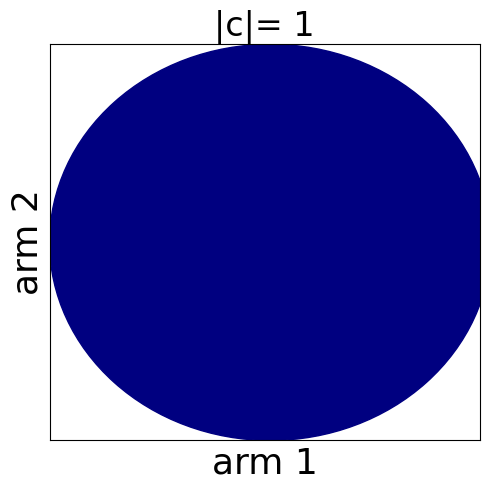

In [129]:
arm = 0
nprune_indx = outcome['nprune_indx']
arm_vs_arm = outcome['armA_vs_armB'][-1]
fig, axs = plt.subplots(1, 1, figsize=(5,5))
row_sum = arm_vs_arm.sum(axis=1)
confm_E = arm_vs_arm / row_sum[:, np.newaxis]
mtx = arm_vs_arm / np.max(arm_vs_arm) 
for l in range(model_order):
    for col in range(model_order):
        xy = np.array([col, l])
        axs.add_patch(plt.Circle(xy, radius=mtx[l, col], color='Navy'))
axs.set_xlim([-1, model_order - .05])
axs.set_ylim([-1, model_order])
axs.invert_yaxis()
axs.set_yticks([])
axs.set_xticks([])
axs.set_yticklabels([])
axs.set_xticklabels([])
plt.title('|c|= ' + str(arm_vs_arm.shape[0]), fontsize=24)
axs.set_xlabel('arm 1', fontsize=26)
axs.set_ylabel('arm 2', fontsize=26)
fig.tight_layout()
plt.savefig(selected_model_file + f'/consensus_T1_vs_T2_K_{model_order}.png', dpi=600)

Average consensus on test cells: 1.0


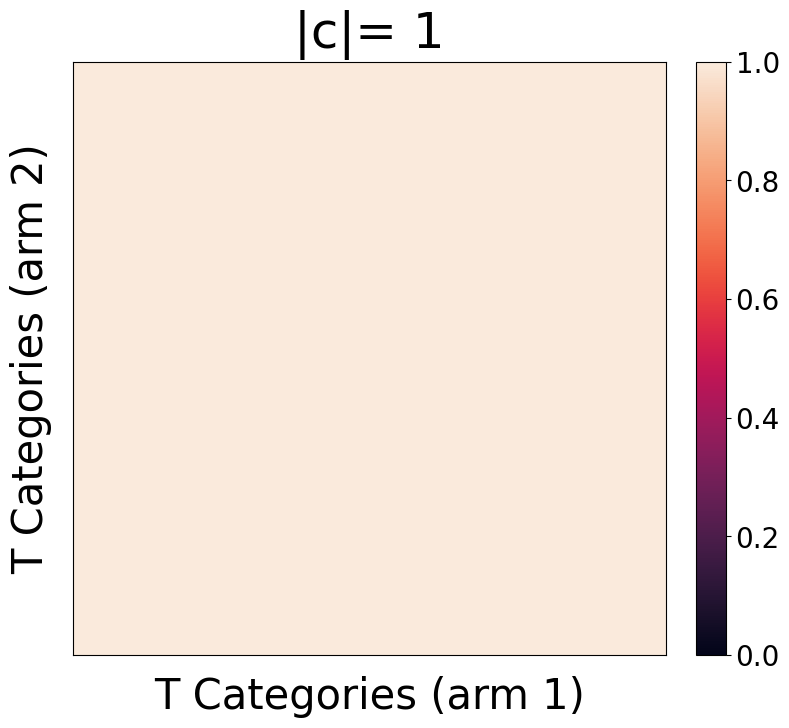

In [131]:
cons_mat = outcome['consensus'][0]

plt.figure(figsize=[8, 8])
ax = plt.gca()
im = ax.imshow(cons_mat, cmap='rocket', vmin=0, vmax=1)
plt.xlabel('T Categories (arm 1)', fontsize=30, labelpad=15)
plt.ylabel('T Categories (arm 2)', fontsize=30, labelpad=15)
plt.xticks([])
plt.yticks([])
plt.title('|c|= ' + str(cons_mat.shape[0]), fontsize=36, pad=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = plt.colorbar(im, cax=cax)
for t in cbar.ax.get_yticklabels():
     t.set_fontsize(20)
cons_lam = np.mean(np.diag(cons_mat)) 

plt.tight_layout()
plt.savefig(selected_model_file + f'/norm_consensus_T1_vs_T2_K_{model_order}.png', dpi=600)
print(f'Average consensus on test cells: {cons_lam}')

In [132]:
_, data_index = data_loader.dataset.tensors
data_index = data_index.numpy().astype(int)
predicted_label = outcome['pred_label'][0][0]
data["discrete_type"] = outcome['pred_label'][0][0]
unique_labels = np.unique(predicted_label)
colors = generate_colors(len(unique_labels))
cell_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each cell
for ic, c in enumerate(unique_labels):
    cell_colors[predicted_label == c] = colors[ic]

batch = np.unique(data['batch'])
colors = generate_colors(len(batch))
batch_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each batch
for ic, c in enumerate(batch):
    batch_colors[data['batch'] == c] = colors[ic]

external_donor_name = np.unique(data['external_donor_name'])
colors = generate_colors(len(external_donor_name))
donor_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each donor
for ic, c in enumerate(external_donor_name):
    donor_colors[data['external_donor_name'] == c] = colors[ic]

sex = np.unique(data['sex'])
colors = generate_colors(len(sex))
sex_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each sex
for ic, c in enumerate(sex):
    sex_colors[data['sex'] == c] = colors[ic]

roi = np.unique(data['injection_target'])
colors = generate_colors(len(roi))
roi_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each roi
for ic, c in enumerate(roi):
    roi_colors[data['injection_target'] == c] = colors[ic]
    
data_id = np.unique(data['dataset'])
colors = generate_colors(len(data_id))
dataset_colors = np.zeros(data['log1p'].shape[0], dtype=object)
# assigning the cluster color to each roi
for ic, c in enumerate(data_id):
    dataset_colors[data['dataset'] == c] = colors[ic]


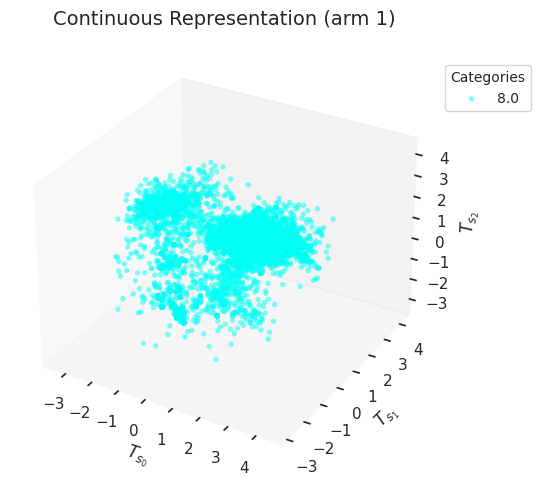

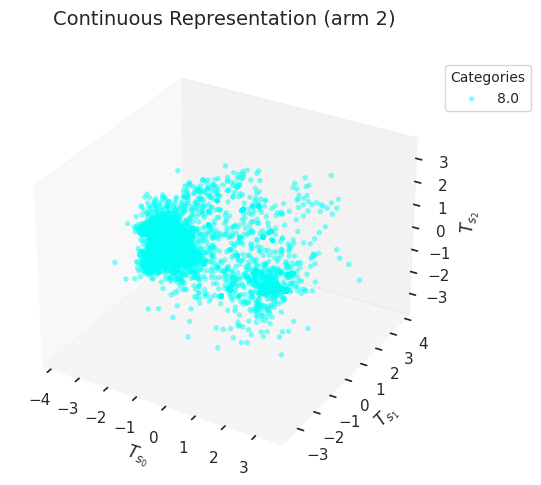

In [139]:
clr_var = cell_colors
label = predicted_label

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'white'})
    scatter = []
    
    if  mixvae.state_dim > 2:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$T_{s_0}$')
        axs.set_ylabel(r'$T_{s_1}$')
        axs.set_zlabel(r'$T_{s_2}$')
    else:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)


    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=14, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .9), fontsize=10, title='Categories', title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


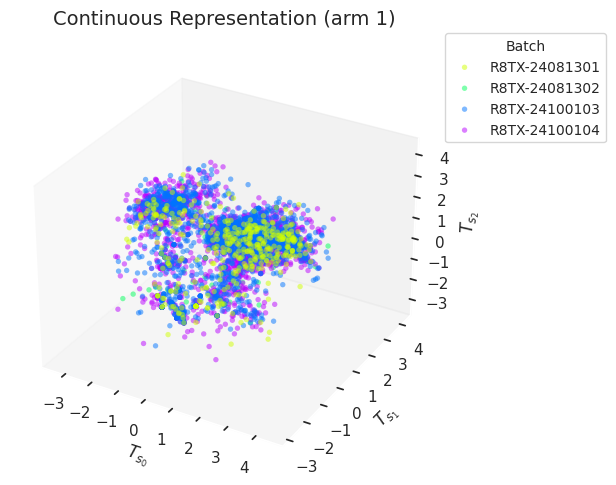

1


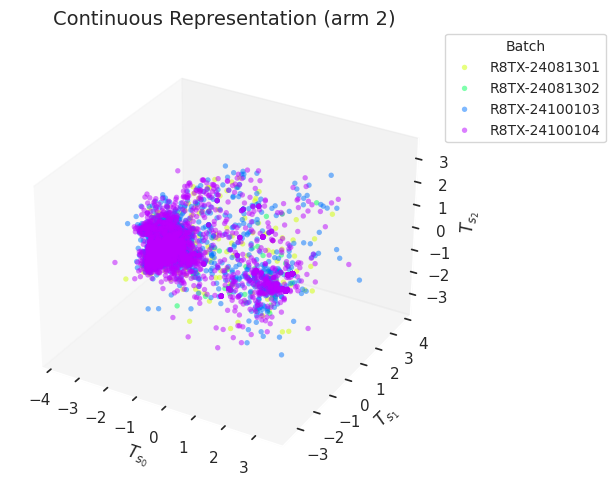

In [138]:
clr_var = batch_colors[data_index]
label = data['batch'][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(7, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'white'})

    if mixvae.state_dim == 2:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    else:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$T_{s_0}$')
        axs.set_ylabel(r'$T_{s_1}$')
        axs.set_zlabel(r'$T_{s_2}$')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=14, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .9), fontsize=10, title='Batch', title_fontsize=10)
    fig.tight_layout()
    plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()

0


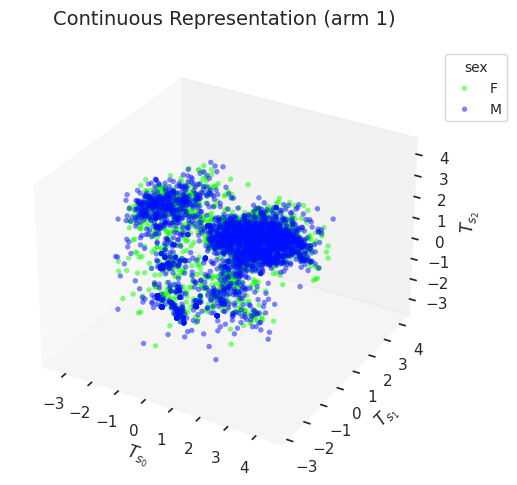

1


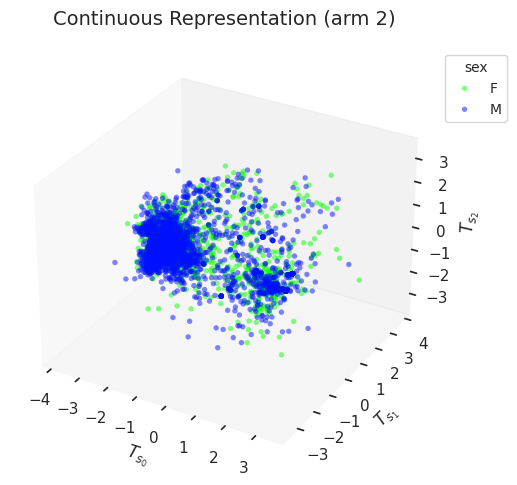

In [140]:
factor = 'sex'
clr_var = sex_colors[data_index]
label = data[factor][data_index]

# Get unique labels and their corresponding colors
unique_labels = np.unique(label)
unique_colors = [clr_var[np.where(label == lbl)[0][0]] for lbl in unique_labels]


for arm in range(mixvae.n_arm):
    print(arm)
    plt.close('all')
    fig = plt.figure(figsize=(6, 5))
    m_size = 15
    alp = .5
    fontsize = 18

    sns.set_theme()
    sns.set(rc={'axes.facecolor':'white'})
    
    if mixvae.state_dim < 3:
        axs = fig.add_subplot(1,1,1)
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0], outcome['state_mu'][arm][indices, 1], color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$s_{T_1}$', fontsize=fontsize)
        axs.set_ylabel(r'$s_{T_2}$', fontsize=fontsize)
        axs.xaxis.set_tick_params(labelsize=10)
        axs.yaxis.set_tick_params(labelsize=10)
    else:
        axs = fig.add_subplot(1,1,1, projection='3d')
        for lbl, clr in zip(unique_labels, unique_colors):
            indices = [i for i, x in enumerate(label) if x == lbl]
            axs.scatter(outcome['state_mu'][arm][indices, 0],
                        outcome['state_mu'][arm][indices, 1],
                        outcome['state_mu'][arm][indices, 2],
                        color=clr, edgecolor='none', s=m_size, alpha=alp, label=lbl)
        axs.set_xlabel(r'$T_{s_0}$')
        axs.set_ylabel(r'$T_{s_1}$')
        axs.set_zlabel(r'$T_{s_2}$')
        

    axs.set_title(f'Continuous Representation (arm {arm+1})', fontsize=14, pad=15)
    axs.grid(False)
    # place legend outside of plot
    axs.legend(loc='center left', bbox_to_anchor=(1, .9), fontsize=10, title=factor, title_fontsize=10)
    fig.tight_layout()
    # plt.savefig(selected_model_file + f'/state_mu_K_{model_order}_arm_{arm}.png', dpi=600)
    plt.show()